# Bearing Autoencoder — PER ASSET EXPERIMENT

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from collections import deque

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
print('TF version:', tf.__version__)

TF version: 2.16.2


In [3]:
data_root = Path("../CWRU_Bearing_NumPy-main/Data")

In [4]:
def load_cwru_signal(bearing_id, regime):
    bearing_rpm = f"{bearing_id} RPM"
    folder = data_root / bearing_rpm

    if regime == "healthy":
        d = np.load(folder / f"{bearing_id}_Normal.npz")
        return d["DE"]

    patterns = {
        "ball":  f"{bearing_id}_B_*_DE12.npz",
        "inner": f"{bearing_id}_IR_*_DE12.npz",
        "outer": f"{bearing_id}_OR*@*_DE12.npz",
    }

    signals = []
    for f in sorted(folder.glob(patterns[regime])):
        d = np.load(f)
        signals.append(d["DE"])

    return np.concatenate(signals)

In [5]:
def make_windows(x, win=1200, step=1200):
    n = (len(x) - win) // step + 1
    return np.stack([x[i*step:i*step+win] for i in range(n)], axis=0)

# ── Compute CWRU MSEs first ─────────────────────────────────────────────
def cwru_mse(signal_1d):
    ws    = make_windows(signal_1d, win=1200, step=1200)
    ws_2d = ws.reshape(ws.shape[0], -1)
    ws_sc = scaler.transform(ws_2d)
    X     = ws_sc[:, :, np.newaxis].astype('float32')
    X_rec = ae.predict(X, verbose=0)
    return np.mean((X - X_rec)**2, axis=(1, 2))

In [6]:
BEARING_IDS = ("1730", "1750", "1772", "1797")
WIN = 1200
STEP = 1200
THRESHOLD_PERCENTILE = 98.0


def load_asset_windows(
    bearing_id: str,
    *,
    win: int = WIN,
    step: int = STEP,
):
    """
    Load and window CWRU exactly as in bearing_autoencoder.ipynb.

    No train/calibration/test split is introduced. This is the ideal,
    asset-specific oracle: all available healthy observations are used
    for model fitting and threshold calibration.
    """
    signals = {
        "healthy": load_cwru_signal(bearing_id, "healthy"),
        "ball": load_cwru_signal(bearing_id, "ball"),
        "inner_race": load_cwru_signal(bearing_id, "inner"),
        "outer_race": load_cwru_signal(bearing_id, "outer"),
    }

    return {
        regime: make_windows(
            signal,
            win=win,
            step=step,
        ).astype(np.float32)
        for regime, signal in signals.items()
    }


def evaluate_scores(
    *,
    bearing_id: str,
    detector_name: str,
    healthy_scores: np.ndarray,
    ball_scores: np.ndarray,
    inner_scores: np.ndarray,
    outer_scores: np.ndarray,
    threshold_percentile: float = THRESHOLD_PERCENTILE,
):
    """
    Common evaluation for all detectors.

    Larger score must always mean more anomalous.
    """
    tau = float(
        np.percentile(
            healthy_scores,
            threshold_percentile,
        )
    )

    return {
        "bearing_id": bearing_id,
        "detector": detector_name,
        "threshold_percentile": threshold_percentile,
        "threshold": tau,
        "healthy_far": 100.0 * np.mean(healthy_scores > tau),
        "ball_dr": 100.0 * np.mean(ball_scores > tau),
        "inner_race_dr": 100.0 * np.mean(inner_scores > tau),
        "outer_race_dr": 100.0 * np.mean(outer_scores > tau),
        "n_healthy": len(healthy_scores),
        "n_ball": len(ball_scores),
        "n_inner_race": len(inner_scores),
        "n_outer_race": len(outer_scores),
    }

#### TEST ONE-CLASS SVM

In [7]:
ocsvm_results = []

for bearing_id in BEARING_IDS:
    print(f"Running asset-specific OC-SVM for {bearing_id} RPM...")

    windows = load_asset_windows(bearing_id)

    # Asset-specific preprocessing fitted only on its real healthy data.
    scaler = StandardScaler()
    X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
    X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
    X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
    X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

    scaler = StandardScaler()

    X_healthy = scaler.fit_transform(X_healthy_raw)
    X_ball = scaler.transform(X_ball_raw)
    X_inner = scaler.transform(X_inner_raw)
    X_outer = scaler.transform(X_outer_raw)

    # PCA is trained only on this asset's healthy observations.
    # It prevents the RBF OC-SVM from operating directly in 1200 dimensions.
    n_components = min(
        32,
        X_healthy.shape[0] - 1,
        X_healthy.shape[1],
    )

    detector = Pipeline(
        [
            (
                "pca",
                PCA(
                    n_components=n_components,
                    random_state=GLOBAL_SEED,
                ),
            ),
            (
                "ocsvm",
                OneClassSVM(
                    kernel="rbf",
                    nu=0.02,
                    gamma="scale",
                ),
            ),
        ]
    )

    detector.fit(X_healthy)

    # sklearn returns larger score_samples for more nominal samples.
    # Negate so that larger always means more anomalous.
    healthy_scores = -detector.score_samples(X_healthy)
    ball_scores = -detector.score_samples(X_ball)
    inner_scores = -detector.score_samples(X_inner)
    outer_scores = -detector.score_samples(X_outer)

    ocsvm_results.append(
        evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific OC-SVM",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )
    )

ocsvm_results = pd.DataFrame(ocsvm_results)
display(ocsvm_results)

Running asset-specific OC-SVM for 1730 RPM...
Running asset-specific OC-SVM for 1750 RPM...
Running asset-specific OC-SVM for 1772 RPM...
Running asset-specific OC-SVM for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race
0,1730,Asset-specific OC-SVM,98.0,-0.999212,2.227723,0.000000,25.123153,4.915730,404,405,406,712
1,1750,Asset-specific OC-SVM,98.0,-1.069604,2.227723,12.345679,25.185185,5.907173,404,405,405,711
2,1772,Asset-specific OC-SVM,98.0,-0.953015,2.233251,0.000000,24.938272,0.000000,403,405,405,712
3,1797,Asset-specific OC-SVM,98.0,-0.604553,2.463054,0.000000,24.938272,0.000000,203,406,405,711


#### TEST ELLIPTICAL ENVELOPE

In [8]:
elliptic_results = []

for bearing_id in BEARING_IDS:
    print(f"Running asset-specific Elliptic Envelope for {bearing_id} RPM...")

    windows = load_asset_windows(bearing_id)

    # Flatten exactly as for OC-SVM
    X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
    X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
    X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
    X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

    # Asset-specific preprocessing fitted only on real healthy data
    scaler = StandardScaler()

    X_healthy = scaler.fit_transform(X_healthy_raw)
    X_ball = scaler.transform(X_ball_raw)
    X_inner = scaler.transform(X_inner_raw)
    X_outer = scaler.transform(X_outer_raw)

    # Robust covariance estimation is unstable in 1200-D with only a few
    # hundred healthy windows, so reduce dimensionality using healthy-only PCA.
    n_components = min(
        16,
        X_healthy.shape[0] - 1,
        X_healthy.shape[1],
    )

    detector = Pipeline(
        [
            (
                "pca",
                PCA(
                    n_components=n_components,
                    random_state=GLOBAL_SEED,
                ),
            ),
            (
                "elliptic",
                EllipticEnvelope(
                    contamination=0.02,
                    support_fraction=None,
                    random_state=GLOBAL_SEED,
                ),
            ),
        ]
    )

    detector.fit(X_healthy)

    # sklearn score_samples:
    # larger = more nominal
    # negate so larger = more anomalous
    healthy_scores = -detector.score_samples(X_healthy)
    ball_scores = -detector.score_samples(X_ball)
    inner_scores = -detector.score_samples(X_inner)
    outer_scores = -detector.score_samples(X_outer)

    elliptic_results.append(
        evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific Elliptic Envelope",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )
    )

elliptic_results = pd.DataFrame(elliptic_results)
display(elliptic_results)

Running asset-specific Elliptic Envelope for 1730 RPM...
Running asset-specific Elliptic Envelope for 1750 RPM...
Running asset-specific Elliptic Envelope for 1772 RPM...
Running asset-specific Elliptic Envelope for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race
0,1730,Asset-specific Elliptic Envelope,98.0,26.031561,2.227723,0.000000,25.369458,6.460674,404,405,406,712
1,1750,Asset-specific Elliptic Envelope,98.0,32.522446,2.227723,2.469136,17.777778,0.562588,404,405,405,711
2,1772,Asset-specific Elliptic Envelope,98.0,39.481334,2.233251,0.000000,0.000000,0.000000,403,405,405,712
3,1797,Asset-specific Elliptic Envelope,98.0,68.972761,2.463054,0.000000,14.567901,0.000000,203,406,405,711


In [9]:
LATENT_DIM = 16
SIG_LEN = 1200

def build_autoencoder(sig_len, latent_dim):
    # ── Encoder ──────────────────────────────────────────────────────────
    inp = keras.Input(shape=(sig_len, 1), name='signal_in')
    x = layers.Conv1D(32,  kernel_size=16, strides=2, padding='same', activation='relu')(inp)
    x = layers.Conv1D(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1D(128, kernel_size=4,  strides=2, padding='same', activation='relu')(x)
    conv_shape = x.shape[1:]            # remember shape before flatten
    x = layers.Flatten()(x)
    latent = layers.Dense(
        latent_dim,
        activity_regularizer=keras.regularizers.l1(1.5e-4),
        name='latent'
    )(x)


    # ── Decoder ──────────────────────────────────────────────────────────
    y = layers.Dense(conv_shape[0] * conv_shape[1], activation='relu')(latent)
    y = layers.Reshape(conv_shape)(y)
    y = layers.Conv1DTranspose(128, kernel_size=4,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(32,  kernel_size=16, strides=2, padding='same', activation='relu')(y)
    # Final layer: crop or pad to exact sig_len, linear activation
    y = layers.Conv1D(1, kernel_size=1, padding='same', activation='linear', name='signal_out')(y)
    y = layers.Cropping1D((0, y.shape[1] - sig_len))(y) if y.shape[1] > sig_len else y

    autoencoder = Model(inp, y, name='bearing_autoencoder')
    encoder     = Model(inp, latent, name='encoder')
    return autoencoder, encoder

ae, encoder = build_autoencoder(SIG_LEN, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

2026-07-24 14:38:56.904694: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-07-24 14:38:56.904743: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-24 14:38:56.904759: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-24 14:38:56.904781: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-24 14:38:56.904800: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "bearing_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_in (InputLayer)          │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 600, 32)        │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       307,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19200)          │       326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 300, 128)       │        65,664 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 600, 64)        │        65,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1200, 32)       │        32,800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_out (Conv1D)             │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,601 (3.23 MB)

 Trainable params: 847,601 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
STABILITY_SEEDS = [7, 21, 42, 84, 126]

ae_results = []

for seed in STABILITY_SEEDS:

    print(f"\n==========================")
    print(f"Seed {seed}")
    print(f"==========================")

    keras.backend.clear_session()

    np.random.seed(seed)
    tf.random.set_seed(seed)

    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        pass

    for bearing_id in BEARING_IDS:

        print(f"Training asset-specific AE for {bearing_id} RPM...")

        windows = load_asset_windows(bearing_id)

        # -------------------------------------------------------
        # preprocessing
        # -------------------------------------------------------

        X_healthy_raw = windows["healthy"].reshape(len(windows["healthy"]), -1)
        X_ball_raw = windows["ball"].reshape(len(windows["ball"]), -1)
        X_inner_raw = windows["inner_race"].reshape(len(windows["inner_race"]), -1)
        X_outer_raw = windows["outer_race"].reshape(len(windows["outer_race"]), -1)

        scaler = StandardScaler()

        X_healthy_sc = scaler.fit_transform(X_healthy_raw).astype(np.float32)
        X_ball_sc = scaler.transform(X_ball_raw).astype(np.float32)
        X_inner_sc = scaler.transform(X_inner_raw).astype(np.float32)
        X_outer_sc = scaler.transform(X_outer_raw).astype(np.float32)

        X_healthy = X_healthy_sc[..., np.newaxis]
        X_ball = X_ball_sc[..., np.newaxis]
        X_inner = X_inner_sc[..., np.newaxis]
        X_outer = X_outer_sc[..., np.newaxis]

        # -------------------------------------------------------
        # model
        # -------------------------------------------------------

        ae, encoder = build_autoencoder(
            sig_len=X_healthy.shape[1],
            latent_dim=LATENT_DIM,
        )

        ae.compile(
            optimizer=keras.optimizers.Adam(1e-3),
            loss="mse",
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=5,
                min_lr=1e-5,
            ),
        ]

        ae.fit(
            X_healthy,
            X_healthy,
            validation_split=0.20,
            epochs=100,
            batch_size=32,
            shuffle=True,
            callbacks=callbacks,
            verbose=0,
        )

        # -------------------------------------------------------
        # scores
        # -------------------------------------------------------

        healthy_rec = ae.predict(X_healthy, verbose=0)
        ball_rec = ae.predict(X_ball, verbose=0)
        inner_rec = ae.predict(X_inner, verbose=0)
        outer_rec = ae.predict(X_outer, verbose=0)

        healthy_scores = np.mean((X_healthy - healthy_rec) ** 2, axis=(1, 2))
        ball_scores    = np.mean((X_ball    - ball_rec)    ** 2, axis=(1, 2))
        inner_scores   = np.mean((X_inner   - inner_rec)   ** 2, axis=(1, 2))
        outer_scores   = np.mean((X_outer   - outer_rec)   ** 2, axis=(1, 2))

        row = evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific AE",
            healthy_scores=healthy_scores,
            ball_scores=ball_scores,
            inner_scores=inner_scores,
            outer_scores=outer_scores,
        )

        row["seed"] = seed

        ae_results.append(row)

# -------------------------------------------------------
# final dataframe
# -------------------------------------------------------

ae_results = pd.DataFrame(ae_results)

display(ae_results)


Seed 7
Training asset-specific AE for 1730 RPM...


2026-07-24 14:38:58.265153: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...

Seed 21
Training asset-specific AE for 1730 RPM...
Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...

Seed 42
Training asset-specific AE for 1730 RPM...
Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...

Seed 84
Training asset-specific AE for 1730 RPM...
Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...

Seed 126
Training asset-specific AE for 1730 RPM...
Training asset-specific AE for 1750 RPM...
Training asset-specific AE for 1772 RPM...
Training asset-specific AE for 1797 RPM...


,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,seed
0,1730,Asset-specific AE,98.0,0.658501,2.227723,100.0,100.0,100.0,404,405,406,712,7
1,1750,Asset-specific AE,98.0,0.666244,2.227723,100.0,100.0,100.0,404,405,405,711,7
2,1772,Asset-specific AE,98.0,0.883316,2.233251,100.0,100.0,100.0,403,405,405,712,7
3,1797,Asset-specific AE,98.0,0.446139,2.463054,100.0,100.0,100.0,203,406,405,711,7
4,1730,Asset-specific AE,98.0,0.672507,2.227723,100.0,100.0,100.0,404,405,406,712,21
5,1750,Asset-specific AE,98.0,1.164796,2.227723,100.0,100.0,100.0,404,405,405,711,21
6,1772,Asset-specific AE,98.0,0.610576,2.233251,100.0,100.0,100.0,403,405,405,712,21
7,1797,Asset-specific AE,98.0,0.473301,2.463054,100.0,100.0,100.0,203,406,405,711,21
8,1730,Asset-specific AE,98.0,0.619351,2.227723,100.0,100.0,100.0,404,405,406,712,42
9,1750,Asset-specific AE,98.0,0.656872,2.227723,100.0,100.0,100.0,404,405,405,711,42


In [11]:
stability = (
    ae_results
    .groupby("bearing_id")
    .agg(
        healthy_far_mean=("healthy_far", "mean"),
        healthy_far_std=("healthy_far", "std"),
        ball_dr_mean=("ball_dr", "mean"),
        ball_dr_std=("ball_dr", "std"),
        inner_race_dr_mean=("inner_race_dr", "mean"),
        inner_race_dr_std=("inner_race_dr", "std"),
        outer_race_dr_mean=("outer_race_dr", "mean"),
        outer_race_dr_std=("outer_race_dr", "std"),
        threshold_mean=("threshold", "mean"),
        threshold_std=("threshold", "std"),
    )
    .reset_index()
)

display(stability)

,bearing_id,healthy_far_mean,healthy_far_std,ball_dr_mean,ball_dr_std,inner_race_dr_mean,inner_race_dr_std,outer_race_dr_mean,outer_race_dr_std,threshold_mean,threshold_std
0,1730,2.227723,0.0,100.0,0.0,100.0,0.0,100.0,0.0,0.648529,0.020741
1,1750,2.227723,0.0,100.0,0.0,100.0,0.0,100.0,0.0,0.759031,0.226892
2,1772,2.233251,0.0,100.0,0.0,100.0,0.0,100.0,0.0,0.724833,0.148432
3,1797,2.463054,0.0,100.0,0.0,100.0,0.0,100.0,0.0,0.459058,0.026359


### METHOD TEST

In [12]:
# =====================================================================
# TRAIN THE FIXED OEM / SHARED SIMULATOR-TRAINED MODEL
# =====================================================================

from bearing_simulator import CWRU_PARAMS, BearingSignalSimulator

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------

OEM_SEED = 42

keras.backend.clear_session()
keras.utils.set_random_seed(OEM_SEED)
np.random.seed(OEM_SEED)
tf.random.set_seed(OEM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ---------------------------------------------------------------------
# Synthetic dataset configuration
# ---------------------------------------------------------------------

shared_simulator = BearingSignalSimulator(CWRU_PARAMS)
shared_sig_len = len(shared_simulator.t)

SYNTHETIC_REGIMES = [
    "healthy",
    "outer_race",
    "inner_race",
    "ball_fault",
]

SYNTHETIC_LABELS = {
    "healthy": 0,
    "outer_race": 1,
    "inner_race": 2,
    "ball_fault": 3,
}

N_SYNTHETIC_TRAIN = 4_000
N_SYNTHETIC_VAL = 1_000
N_SYNTHETIC_TEST = 750

SHARED_LATENT_DIM = 16
SHARED_THRESHOLD_PERCENTILE = 98.0

print(f"Shared synthetic signal length: {shared_sig_len} samples")


# ---------------------------------------------------------------------
# Generate independent healthy training and validation datasets
# ---------------------------------------------------------------------

X_shared_train_raw = np.asarray(
    [
        shared_simulator.sample("healthy", mc=True)
        for _ in range(N_SYNTHETIC_TRAIN)
    ],
    dtype=np.float32,
)

X_shared_val_raw = np.asarray(
    [
        shared_simulator.sample("healthy", mc=True)
        for _ in range(N_SYNTHETIC_VAL)
    ],
    dtype=np.float32,
)


# ---------------------------------------------------------------------
# Fit preprocessing only on synthetic healthy training data
# ---------------------------------------------------------------------

shared_scaler = StandardScaler()

X_shared_train_sc = shared_scaler.fit_transform(
    X_shared_train_raw
).astype(np.float32)

X_shared_val_sc = shared_scaler.transform(
    X_shared_val_raw
).astype(np.float32)

X_shared_train = X_shared_train_sc[..., np.newaxis]
X_shared_val = X_shared_val_sc[..., np.newaxis]


# ---------------------------------------------------------------------
# Generate a separate synthetic test set
# ---------------------------------------------------------------------

shared_test_by_regime = {}
shared_y_test_parts = []

for regime in SYNTHETIC_REGIMES:
    regime_raw = np.asarray(
        [
            shared_simulator.sample(regime, mc=True)
            for _ in range(N_SYNTHETIC_TEST)
        ],
        dtype=np.float32,
    )

    regime_sc = shared_scaler.transform(
        regime_raw
    ).astype(np.float32)

    shared_test_by_regime[regime] = regime_sc[..., np.newaxis]

    shared_y_test_parts.append(
        np.full(
            N_SYNTHETIC_TEST,
            SYNTHETIC_LABELS[regime],
            dtype=np.int64,
        )
    )

X_shared_test = np.concatenate(
    [
        shared_test_by_regime[regime]
        for regime in SYNTHETIC_REGIMES
    ],
    axis=0,
)

y_shared_test = np.concatenate(
    shared_y_test_parts,
    axis=0,
)

print(
    f"Train: {X_shared_train.shape} | "
    f"Validation: {X_shared_val.shape} | "
    f"Test: {X_shared_test.shape}"
)


# ---------------------------------------------------------------------
# Build and train the fixed shared/OEM autoencoder
# ---------------------------------------------------------------------

shared_ae, shared_encoder = build_autoencoder(
    sig_len=shared_sig_len,
    latent_dim=SHARED_LATENT_DIM,
)

shared_ae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
)

shared_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
    ),
]

shared_history = shared_ae.fit(
    X_shared_train,
    X_shared_train,
    validation_data=(X_shared_val, X_shared_val),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=shared_callbacks,
    verbose=1,
)


# ---------------------------------------------------------------------
# Calibrate the simulator threshold on held-out healthy validation data
# ---------------------------------------------------------------------

X_shared_val_rec = shared_ae.predict(
    X_shared_val,
    verbose=0,
)

shared_val_mse = np.mean(
    np.square(X_shared_val - X_shared_val_rec),
    axis=(1, 2),
)

shared_tau_mc = float(
    np.percentile(
        shared_val_mse,
        SHARED_THRESHOLD_PERCENTILE,
    )
)

print(
    f"\nSynthetic validation threshold "
    f"τ_MC (p{SHARED_THRESHOLD_PERCENTILE:.0f}) "
    f"= {shared_tau_mc:.6f}"
)


# ---------------------------------------------------------------------
# Evaluate on the independent synthetic test set
# ---------------------------------------------------------------------

X_shared_test_rec = shared_ae.predict(
    X_shared_test,
    verbose=0,
)

shared_test_mse = np.mean(
    np.square(X_shared_test - X_shared_test_rec),
    axis=(1, 2),
)


def _synthetic_rate(regime: str) -> float:
    regime_mask = (
        y_shared_test == SYNTHETIC_LABELS[regime]
    )

    return 100.0 * float(
        np.mean(
            shared_test_mse[regime_mask] > shared_tau_mc
        )
    )


synthetic_ae_results = pd.DataFrame(
    [
        {
            "bearing_id": "Synthetic",
            "detector": "Shared simulator-trained AE",
            "threshold_percentile": SHARED_THRESHOLD_PERCENTILE,
            "threshold": shared_tau_mc,
            "healthy_far": _synthetic_rate("healthy"),
            "ball_dr": _synthetic_rate("ball_fault"),
            "inner_race_dr": _synthetic_rate("inner_race"),
            "outer_race_dr": _synthetic_rate("outer_race"),
            "n_healthy": N_SYNTHETIC_TEST,
            "n_ball": N_SYNTHETIC_TEST,
            "n_inner_race": N_SYNTHETIC_TEST,
            "n_outer_race": N_SYNTHETIC_TEST,
            "training_seed": OEM_SEED,
            "n_train": N_SYNTHETIC_TRAIN,
            "n_validation": N_SYNTHETIC_VAL,
        }
    ]
)

display(synthetic_ae_results)


# ---------------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------------

assert shared_ae is not None
assert shared_scaler is not None
assert shared_sig_len == X_shared_train.shape[1]
assert np.isfinite(shared_tau_mc)

print("\nFixed OEM artifacts created:")
print("  shared_ae")
print("  shared_encoder")
print("  shared_scaler")
print("  shared_tau_mc")
print("  shared_history")

Shared synthetic signal length: 1200 samples
Train: (4000, 1200, 1) | Validation: (1000, 1200, 1) | Test: (3000, 1200, 1)
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.2822 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0776 - val_loss: 0.0707 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0690 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0688 - val_loss: 0.0696 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0682 - val_loss: 0.0682 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0670 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0655 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0669 - val_loss: 0.0662 - lear

,bearing_id,detector,threshold_percentile,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_healthy,n_ball,n_inner_race,n_outer_race,training_seed,n_train,n_validation
0,Synthetic,Shared simulator-trained AE,98.0,0.102678,1.333333,95.6,100.0,100.0,750,750,750,750,42,4000,1000



Fixed OEM artifacts created:
  shared_ae
  shared_encoder
  shared_scaler
  shared_tau_mc
  shared_history


### DOMAIN ADAPTATION ###

In [13]:
TARGET_PERCENTILE = 98.0
WARMUP_SIZE = 100
WINDOW_SIZE = 100
MIN_WARMUP_SAMPLES = 20

CONVERGENCE_LOOKBACK = 10
CONVERGENCE_TOLERANCE = 0.01
CONVERGENCE_CONSECUTIVE = 10

In [14]:
# =====================================================================
# Online operational-radius estimator
# =====================================================================

class AdaptiveOperationalRadius:
    """
    Online empirical-quantile estimator.

    The globally shared quantity is the target nominal coverage
    (e.g. 98%), not a z-score or an absolute threshold.

    The local operational radius is estimated as the empirical
    percentile of the accepted nominal residuals.
    """

    def __init__(
        self,
        percentile=98.0,
        window_size=100,
        min_samples=20,
    ):
        if not 0.0 < percentile < 100.0:
            raise ValueError("percentile must be between 0 and 100.")

        if window_size < 2:
            raise ValueError("window_size must be at least 2.")

        if min_samples < 2:
            raise ValueError("min_samples must be at least 2.")

        if min_samples > window_size:
            raise ValueError(
                "min_samples cannot be larger than window_size."
            )

        self.percentile = float(percentile)
        self.window_size = int(window_size)
        self.min_samples = int(min_samples)

        self.buf = deque(maxlen=self.window_size)

    def update(self, mse_value):
        """
        Add one nominal residual and update the operational radius.

        Returns
        -------
        tau : float
            Current operational radius. NaN until min_samples is reached.
        """
        self.buf.append(float(mse_value))

        if len(self.buf) < self.min_samples:
            return np.nan

        arr = np.asarray(self.buf, dtype=np.float64)

        return float(
            np.percentile(
                arr,
                self.percentile,
            )
        )

    def warmup_trace(self, mse_sequence):
        """
        Process an entire warm-up sequence and return tau(t).
        """
        history_tau = []

        for mse_value in mse_sequence:
            history_tau.append(
                self.update(mse_value)
            )

        return np.asarray(history_tau, dtype=np.float64)


# =====================================================================
# Convergence utilities
# =====================================================================

def operational_radius_convergence_trace(
    tau_history,
    *,
    lookback=10,
    eps=1e-12,
):
    """
    Relative variation of tau over a fixed look-back interval.

    C(t) = |tau(t) - tau(t-L)| / max(|tau(t-L)|, eps)
    """
    tau_history = np.asarray(tau_history, dtype=np.float64)

    convergence = np.full(
        tau_history.shape,
        np.nan,
        dtype=np.float64,
    )

    for t in range(lookback, len(tau_history)):
        current = tau_history[t]
        previous = tau_history[t - lookback]

        if np.isfinite(current) and np.isfinite(previous):
            convergence[t] = (
                abs(current - previous)
                / max(abs(previous), eps)
            )

    return convergence


def find_convergence_index(
    tau_history,
    *,
    lookback=10,
    tolerance=0.01,
    consecutive=10,
):
    """
    Return the first index at which the operational radius remains
    stable for `consecutive` updates.

    Returns None when convergence is not observed.
    """
    convergence = operational_radius_convergence_trace(
        tau_history,
        lookback=lookback,
    )

    stable_count = 0

    for t, value in enumerate(convergence):
        if np.isfinite(value) and value < tolerance:
            stable_count += 1

            if stable_count >= consecutive:
                return t
        else:
            stable_count = 0

    return None


# =====================================================================
# Shared simulator-trained AE applied unchanged to CWRU
# =====================================================================

def run_experiment(
    bearing_id,
    *,
    target_percentile=TARGET_PERCENTILE,
    warmup_size=100,
    operational_window_size=WINDOW_SIZE,
    min_warmup_samples=MIN_WARMUP_SAMPLES,
    convergence_lookback=10,
    convergence_tolerance=0.01,
    convergence_consecutive=10,
):
    """
    Evaluate the simulator-trained shared AE on one CWRU condition.

    Important
    ---------
    - `ae` and `scaler` are the models trained on synthetic healthy data.
    - They are transferred unchanged to CWRU.
    - All CWRU healthy windows are used only for the field-oracle p98.
    - Only the first `warmup_size` healthy windows are used by the
      online operational-radius estimator.
    """

    # -----------------------------------------------------------------
    # Load complete CWRU signals
    # -----------------------------------------------------------------

    normal_signal = load_cwru_signal(bearing_id, "healthy")
    ball_signal   = load_cwru_signal(bearing_id, "ball")
    inner_signal  = load_cwru_signal(bearing_id, "inner")
    outer_signal  = load_cwru_signal(bearing_id, "outer")

    print(f"\nCWRU operating condition: {bearing_id} RPM")
    print("Normal:", normal_signal.shape)
    print("Ball:  ", ball_signal.shape)
    print("Inner: ", inner_signal.shape)
    print("Outer: ", outer_signal.shape)

    # -----------------------------------------------------------------
    # Apply synthetic scaler and shared AE unchanged
    # -----------------------------------------------------------------

    def cwru_mse(signal):
        windows = make_windows(
            signal,
            win=shared_sig_len,
            step=shared_sig_len,
        )

        windows_2d = windows.reshape(
            windows.shape[0],
            -1,
        )

        # This scaler was fitted on synthetic nominal data.
        windows_scaled = scaler.transform(
            windows_2d
        )

        X = windows_scaled[
            :,
            :,
            np.newaxis,
        ].astype(np.float32)

        X_rec = ae.predict(
            X,
            verbose=0,
        )

        return np.mean(
            np.square(X - X_rec),
            axis=(1, 2),
        )

    # -----------------------------------------------------------------
    # Synthetic absolute threshold
    # -----------------------------------------------------------------

    X_train_rec = ae.predict(
        X_train,
        verbose=0,
    )

    mse_mc_healthy = np.mean(
        np.square(X_train - X_train_rec),
        axis=(1, 2),
    )

    tau_mc = float(
        np.percentile(
            mse_mc_healthy,
            target_percentile,
        )
    )

    # -----------------------------------------------------------------
    # CWRU residuals
    # -----------------------------------------------------------------

    mse_healthy = cwru_mse(normal_signal)
    mse_ball = cwru_mse(ball_signal)
    mse_inner = cwru_mse(inner_signal)
    mse_outer = cwru_mse(outer_signal)

    print(
        "Windows → "
        f"healthy:{len(mse_healthy)} "
        f"ball:{len(mse_ball)} "
        f"inner:{len(mse_inner)} "
        f"outer:{len(mse_outer)}"
    )

    # -----------------------------------------------------------------
    # Field oracle: all available healthy CWRU windows
    # -----------------------------------------------------------------

    tau_field_oracle = float(
        np.percentile(
            mse_healthy,
            target_percentile,
        )
    )

    # -----------------------------------------------------------------
    # Online field deployment: only initial healthy warm-up
    # -----------------------------------------------------------------

    if warmup_size is None:
        warmup_size = len(mse_healthy)

    warmup_size = min(
        int(warmup_size),
        len(mse_healthy),
    )

    if warmup_size < min_warmup_samples:
        raise ValueError(
            f"warmup_size={warmup_size} is smaller than "
            f"min_warmup_samples={min_warmup_samples}."
        )

    mse_warmup = mse_healthy[:warmup_size]

    adaptive = AdaptiveOperationalRadius(
        percentile=target_percentile,
        window_size=min(
            operational_window_size,
            warmup_size,
        ),
        min_samples=min(
            min_warmup_samples,
            warmup_size,
        ),
    )

    tau_history = adaptive.warmup_trace(
        mse_warmup
    )

    valid_tau = tau_history[
        np.isfinite(tau_history)
    ]

    if len(valid_tau) == 0:
        raise RuntimeError(
            "The online operational radius did not initialize."
        )

    tau_online = float(valid_tau[-1])

    convergence_index = find_convergence_index(
        tau_history,
        lookback=convergence_lookback,
        tolerance=convergence_tolerance,
        consecutive=convergence_consecutive,
    )

    # -----------------------------------------------------------------
    # Metrics
    # -----------------------------------------------------------------

    def alarm_rate(scores, threshold):
        return 100.0 * float(
            np.mean(scores > threshold)
        )

    thresholds = {
        "absolute_mc": tau_mc,
        "field_oracle": tau_field_oracle,
        "online_radius": tau_online,
    }

    rows = []

    for threshold_name, threshold_value in thresholds.items():
        rows.append(
            {
                "bearing_id": str(bearing_id),
                "detector": "Shared simulator-trained AE",
                "calibration": threshold_name,
                "threshold_percentile": target_percentile,
                "threshold": threshold_value,

                "healthy_far": alarm_rate(
                    mse_healthy,
                    threshold_value,
                ),
                "ball_dr": alarm_rate(
                    mse_ball,
                    threshold_value,
                ),
                "inner_race_dr": alarm_rate(
                    mse_inner,
                    threshold_value,
                ),
                "outer_race_dr": alarm_rate(
                    mse_outer,
                    threshold_value,
                ),

                "n_healthy": len(mse_healthy),
                "n_ball": len(mse_ball),
                "n_inner_race": len(mse_inner),
                "n_outer_race": len(mse_outer),

                "warmup_size": (
                    0
                    if threshold_name == "absolute_mc"
                    else (
                        len(mse_healthy)
                        if threshold_name == "field_oracle"
                        else warmup_size
                    )
                ),

                "convergence_index": (
                    convergence_index
                    if threshold_name == "online_radius"
                    else np.nan
                ),
            }
        )

    results_table = pd.DataFrame(rows)

    print("\nThresholds")
    print(f"τ_MC absolute       = {tau_mc:.6f}")
    print(f"τ_field oracle p98 = {tau_field_oracle:.6f}")
    print(f"τ_online           = {tau_online:.6f}")

    if convergence_index is None:
        print("Operational-radius convergence: not detected")
    else:
        print(
            "Operational-radius convergence detected at "
            f"warm-up window {convergence_index}."
        )

    display(results_table)

    return {
        "bearing_id": str(bearing_id),

        "mse_mc_healthy": mse_mc_healthy,
        "mse_healthy": mse_healthy,
        "mse_ball": mse_ball,
        "mse_inner": mse_inner,
        "mse_outer": mse_outer,

        "mse_warmup": mse_warmup,
        "tau_history": tau_history,

        "tau_mc": tau_mc,
        "tau_field_oracle": tau_field_oracle,
        "tau_online": tau_online,

        "convergence_index": convergence_index,
        "results_table": results_table,
    }


# =====================================================================
# Plotting
# =====================================================================

def plot_experiment(result):
    """
    Plot field residual distribution and online radius convergence.
    """

    bearing_id = result["bearing_id"]

    mse_healthy = result["mse_healthy"]
    mse_warmup = result["mse_warmup"]

    tau_mc = result["tau_mc"]
    tau_field_oracle = result["tau_field_oracle"]
    tau_online = result["tau_online"]

    tau_history = result["tau_history"]
    convergence_index = result["convergence_index"]

    # -----------------------------------------------------------------
    # Healthy residual distribution
    # -----------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.hist(
        mse_healthy,
        bins=50,
        density=True,
        alpha=0.60,
        label="Healthy CWRU",
    )

    ax.axvline(
        tau_mc,
        linestyle="--",
        linewidth=1.5,
        label=f"Absolute simulator τ = {tau_mc:.4f}",
    )

    ax.axvline(
        tau_field_oracle,
        linestyle="--",
        linewidth=1.5,
        label=f"Field oracle p98 = {tau_field_oracle:.4f}",
    )

    ax.axvline(
        tau_online,
        linestyle="--",
        linewidth=1.5,
        label=f"Online radius = {tau_online:.4f}",
    )

    ax.set_xlabel("Reconstruction MSE")
    ax.set_ylabel("Density")
    ax.set_title(
        f"Healthy CWRU residual distribution — {bearing_id} RPM"
    )

    ax.legend()
    ax.grid(
        True,
        alpha=0.25,
        axis="y",
    )

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------
    # Operational-radius convergence
    # -----------------------------------------------------------------

    steps = np.arange(
        len(tau_history)
    )

    fig, ax = plt.subplots(
        figsize=(11, 5)
    )

    ax.plot(
        steps,
        tau_history,
        linewidth=1.5,
        label="Online operational radius",
    )

    ax.axhline(
        tau_field_oracle,
        linestyle="--",
        linewidth=1.2,
        label=f"Full-data field oracle = {tau_field_oracle:.4f}",
    )

    if convergence_index is not None:
        ax.axvline(
            convergence_index,
            linestyle=":",
            linewidth=1.2,
            label=f"Convergence = {convergence_index}",
        )

    ax.set_xlabel("Healthy warm-up window")
    ax.set_ylabel("Operational radius")
    ax.set_title(
        f"Operational-radius convergence — {bearing_id} RPM"
    )

    ax.legend()
    ax.grid(
        True,
        alpha=0.25,
    )

    plt.tight_layout()
    plt.show()

    print(
        f"Full healthy windows: {len(mse_healthy)}\n"
        f"Online warm-up windows: {len(mse_warmup)}\n"
        f"Field oracle p98: {tau_field_oracle:.6f}\n"
        f"Online radius: {tau_online:.6f}"
    )

In [15]:
# =====================================================================
# STABILITY UNDER LOCAL WARM-UP SAMPLING VARIABILITY
# Fixed OEM model; different 100-window field initialization samples
# =====================================================================

STABILITY_SEEDS = [7, 21, 42, 84, 126]


# ---------------------------------------------------------------------
# Sanity checks
# The fixed OEM artifacts and common experimental constants must exist.
# ---------------------------------------------------------------------

required_objects = [
    "shared_ae",
    "shared_scaler",
    "shared_sig_len",
    "BEARING_IDS",
    "WARMUP_SIZE",
    "TARGET_PERCENTILE",
    "MIN_WARMUP_SAMPLES",
    "CONVERGENCE_LOOKBACK",
    "CONVERGENCE_TOLERANCE",
    "CONVERGENCE_CONSECUTIVE",
    "AdaptiveOperationalRadius",
    "find_convergence_index",
    "make_windows",
    "load_cwru_signal",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing)
        + ". Run the preceding model-training and operational-radius "
          "definition cells first."
    )


# Use the same non-overlapping window length employed by the shared model.
# This avoids maintaining an independent hard-coded STEP value.
STEP = int(shared_sig_len)


# ---------------------------------------------------------------------
# Helper: apply the fixed simulator-trained model to one field signal
# ---------------------------------------------------------------------

def shared_cwru_mse(signal):
    """
    Compute reconstruction residuals for one complete CWRU signal using
    the fixed simulator-trained scaler and autoencoder.

    No field retraining, fitting, or preprocessing adaptation is performed.
    """

    windows = make_windows(
        signal,
        win=shared_sig_len,
        step=STEP,
    ).astype(np.float32)

    if len(windows) == 0:
        raise ValueError(
            "The supplied signal does not contain a complete "
            f"{shared_sig_len}-sample window."
        )

    windows_2d = windows.reshape(
        windows.shape[0],
        -1,
    )

    windows_scaled = shared_scaler.transform(
        windows_2d
    ).astype(np.float32)

    X = windows_scaled[..., np.newaxis]

    X_rec = shared_ae.predict(
        X,
        verbose=0,
    )

    return np.mean(
        np.square(X - X_rec),
        axis=(1, 2),
    )


# ---------------------------------------------------------------------
# Compute field residuals once
#
# These residuals remain fixed across stability seeds. Only the healthy
# observations selected for local warm-up, and their arrival order, change.
# ---------------------------------------------------------------------

field_residuals = {}

for bearing_id in BEARING_IDS:

    bearing_key = str(bearing_id)

    print(
        f"Computing fixed-model residuals for "
        f"{bearing_key} RPM..."
    )

    field_residuals[bearing_key] = {
        "healthy": shared_cwru_mse(
            load_cwru_signal(
                bearing_id,
                "healthy",
            )
        ),
        "ball": shared_cwru_mse(
            load_cwru_signal(
                bearing_id,
                "ball",
            )
        ),
        "inner_race": shared_cwru_mse(
            load_cwru_signal(
                bearing_id,
                "inner",
            )
        ),
        "outer_race": shared_cwru_mse(
            load_cwru_signal(
                bearing_id,
                "outer",
            )
        ),
    }


# ---------------------------------------------------------------------
# Stability experiment
#
# For each seed and operating condition:
#
# 1. Randomly select 100 healthy windows for warm-up.
# 2. Use the random permutation as their simulated arrival order.
# 3. Estimate the empirical p98 radius sequentially.
# 4. Evaluate healthy FAR on the held-out healthy windows only.
# 5. Evaluate fault DR on the complete fault datasets.
# ---------------------------------------------------------------------

warmup_stability_rows = []
warmup_traces = {}

for seed in STABILITY_SEEDS:

    print("\n" + "=" * 72)
    print(f"Warm-up sampling seed: {seed}")
    print("=" * 72)

    for bearing_id in BEARING_IDS:

        bearing_key = str(bearing_id)
        residuals = field_residuals[bearing_key]

        healthy_scores = np.asarray(
            residuals["healthy"],
            dtype=np.float64,
        )

        ball_scores = np.asarray(
            residuals["ball"],
            dtype=np.float64,
        )

        inner_scores = np.asarray(
            residuals["inner_race"],
            dtype=np.float64,
        )

        outer_scores = np.asarray(
            residuals["outer_race"],
            dtype=np.float64,
        )

        n_healthy = len(healthy_scores)

        if WARMUP_SIZE >= n_healthy:
            raise ValueError(
                f"{bearing_key} RPM: "
                f"WARMUP_SIZE={WARMUP_SIZE} must be smaller than "
                f"n_healthy={n_healthy}, so that an independent "
                "healthy evaluation set remains."
            )

        if WARMUP_SIZE < MIN_WARMUP_SAMPLES:
            raise ValueError(
                f"WARMUP_SIZE={WARMUP_SIZE} is smaller than "
                f"MIN_WARMUP_SAMPLES={MIN_WARMUP_SAMPLES}."
            )

        # -------------------------------------------------------------
        # Reproducible random initialization sample
        #
        # Adding the bearing identifier ensures that each RPM condition
        # receives an independent permutation under the same base seed.
        #
        # The permutation determines both:
        # - which healthy observations enter the warm-up;
        # - the order in which those observations arrive.
        # -------------------------------------------------------------

        rng = np.random.default_rng(
            seed + int(bearing_id)
        )

        permutation = rng.permutation(
            n_healthy
        )

        warmup_indices = permutation[
            :WARMUP_SIZE
        ]

        healthy_test_indices = permutation[
            WARMUP_SIZE:
        ]

        warmup_scores = healthy_scores[
            warmup_indices
        ]

        healthy_test_scores = healthy_scores[
            healthy_test_indices
        ]


        # -------------------------------------------------------------
        # Sequential local operational-radius estimation
        # -------------------------------------------------------------

        adaptive = AdaptiveOperationalRadius(
            percentile=TARGET_PERCENTILE,
            window_size=WARMUP_SIZE,
            min_samples=MIN_WARMUP_SAMPLES,
        )

        tau_history = adaptive.warmup_trace(
            warmup_scores
        )

        valid_tau = tau_history[
            np.isfinite(tau_history)
        ]

        if len(valid_tau) == 0:
            raise RuntimeError(
                f"{bearing_key} RPM, seed {seed}: "
                "the local operational radius did not initialize."
            )

        # The last valid sequential estimate is the deployed threshold
        # after the prescribed 100-window warm-up.
        tau_online = float(
            valid_tau[-1]
        )


        # -------------------------------------------------------------
        # Convergence detection
        #
        # find_convergence_index returns a zero-based Python index.
        # convergence_window converts that index into an intuitive
        # one-based number of observed warm-up windows.
        # -------------------------------------------------------------

        convergence_index = find_convergence_index(
            tau_history,
            lookback=CONVERGENCE_LOOKBACK,
            tolerance=CONVERGENCE_TOLERANCE,
            consecutive=CONVERGENCE_CONSECUTIVE,
        )

        convergence_window = (
            convergence_index + 1
            if convergence_index is not None
            else np.nan
        )


        # -------------------------------------------------------------
        # Complete-data field oracle
        #
        # This value uses every available healthy window and is used
        # only as a retrospective reference.
        # -------------------------------------------------------------

        tau_field_oracle = float(
            np.percentile(
                healthy_scores,
                TARGET_PERCENTILE,
            )
        )

        tau_absolute_error = abs(
            tau_online - tau_field_oracle
        )

        tau_relative_error_pct = (
            100.0
            * tau_absolute_error
            / max(
                abs(tau_field_oracle),
                1e-12,
            )
        )


        # -------------------------------------------------------------
        # Evaluation helper
        # -------------------------------------------------------------

        def alarm_rate(scores):
            return 100.0 * float(
                np.mean(
                    scores > tau_online
                )
            )


        # -------------------------------------------------------------
        # Store one result row for this RPM and seed
        # -------------------------------------------------------------

        row = {
            "bearing_id": bearing_key,
            "seed": seed,

            "detector": (
                "Fixed shared simulator-trained AE"
            ),

            "calibration": (
                "random_100_window_online_p98"
            ),

            "threshold_percentile": (
                TARGET_PERCENTILE
            ),

            "tau_online": tau_online,
            "tau_field_oracle": tau_field_oracle,
            "tau_absolute_error": tau_absolute_error,
            "tau_relative_error_pct": (
                tau_relative_error_pct
            ),

            # Healthy FAR is evaluated only on observations that were
            # not used for local calibration.
            "healthy_far": alarm_rate(
                healthy_test_scores
            ),

            "ball_dr": alarm_rate(
                ball_scores
            ),

            "inner_race_dr": alarm_rate(
                inner_scores
            ),

            "outer_race_dr": alarm_rate(
                outer_scores
            ),

            "warmup_size": len(
                warmup_scores
            ),

            "n_healthy_test": len(
                healthy_test_scores
            ),

            "n_ball": len(
                ball_scores
            ),

            "n_inner_race": len(
                inner_scores
            ),

            "n_outer_race": len(
                outer_scores
            ),

            "convergence_index": (
                convergence_index
                if convergence_index is not None
                else np.nan
            ),

            "convergence_window": (
                convergence_window
            ),
        }

        warmup_stability_rows.append(
            row
        )


        # -------------------------------------------------------------
        # Store detailed traces for later figures or auditing
        # -------------------------------------------------------------

        warmup_traces[
            (bearing_key, seed)
        ] = {
            "warmup_indices": (
                warmup_indices.copy()
            ),

            "healthy_test_indices": (
                healthy_test_indices.copy()
            ),

            "warmup_scores": (
                warmup_scores.copy()
            ),

            "healthy_test_scores": (
                healthy_test_scores.copy()
            ),

            "tau_history": (
                tau_history.copy()
            ),

            "tau_online": (
                tau_online
            ),

            "tau_field_oracle": (
                tau_field_oracle
            ),

            "tau_absolute_error": (
                tau_absolute_error
            ),

            "tau_relative_error_pct": (
                tau_relative_error_pct
            ),

            "convergence_index": (
                convergence_index
            ),

            "convergence_window": (
                convergence_window
            ),
        }


        # -------------------------------------------------------------
        # Progress output
        # -------------------------------------------------------------

        convergence_text = (
            f"{int(convergence_window)}"
            if np.isfinite(convergence_window)
            else "not detected"
        )

        print(
            f"{bearing_key} RPM | "
            f"tau_online={tau_online:.6f} | "
            f"oracle={tau_field_oracle:.6f} | "
            f"error={tau_relative_error_pct:.2f}% | "
            f"FAR={row['healthy_far']:.2f}% | "
            f"Ball={row['ball_dr']:.2f}% | "
            f"Inner={row['inner_race_dr']:.2f}% | "
            f"Outer={row['outer_race_dr']:.2f}% | "
            f"Conv. window={convergence_text}"
        )


# ---------------------------------------------------------------------
# Long-form results
# One row per RPM and stability seed
# ---------------------------------------------------------------------

warmup_stability_results = pd.DataFrame(
    warmup_stability_rows
)

display(
    warmup_stability_results
)


# ---------------------------------------------------------------------
# Summary by operating condition
#
# Variability here is calculated across the five warm-up seeds separately
# for each RPM condition.
# ---------------------------------------------------------------------

warmup_stability_by_bearing = (
    warmup_stability_results
    .groupby(
        "bearing_id",
        as_index=False,
    )
    .agg(
        tau_online_mean=(
            "tau_online",
            "mean",
        ),

        tau_online_std=(
            "tau_online",
            "std",
        ),

        tau_field_oracle=(
            "tau_field_oracle",
            "first",
        ),

        tau_relative_error_mean=(
            "tau_relative_error_pct",
            "mean",
        ),

        tau_relative_error_std=(
            "tau_relative_error_pct",
            "std",
        ),

        healthy_far_mean=(
            "healthy_far",
            "mean",
        ),

        healthy_far_std=(
            "healthy_far",
            "std",
        ),

        ball_dr_mean=(
            "ball_dr",
            "mean",
        ),

        ball_dr_std=(
            "ball_dr",
            "std",
        ),

        inner_race_dr_mean=(
            "inner_race_dr",
            "mean",
        ),

        inner_race_dr_std=(
            "inner_race_dr",
            "std",
        ),

        outer_race_dr_mean=(
            "outer_race_dr",
            "mean",
        ),

        outer_race_dr_std=(
            "outer_race_dr",
            "std",
        ),

        convergence_mean=(
            "convergence_window",
            "mean",
        ),

        convergence_std=(
            "convergence_window",
            "std",
        ),
    )
)

display(
    warmup_stability_by_bearing
)


# ---------------------------------------------------------------------
# Seed-level fleet averages
#
# For each seed, first average across the four RPM conditions.
# This keeps RPM heterogeneity separate from warm-up sampling variability.
# ---------------------------------------------------------------------

summary_columns = [
    "healthy_far",
    "ball_dr",
    "inner_race_dr",
    "outer_race_dr",
    "tau_relative_error_pct",
    "convergence_window",
]

warmup_seed_means = (
    warmup_stability_results
    .groupby("seed")[
        summary_columns
    ]
    .mean()
)

display(
    warmup_seed_means
)


# ---------------------------------------------------------------------
# Global stability summary across seeds
#
# These statistics describe variability between the five independent
# warm-up realizations after averaging across RPM conditions.
# ---------------------------------------------------------------------

warmup_global_summary = pd.DataFrame(
    {
        "mean": warmup_seed_means.mean(),
        "std": warmup_seed_means.std(
            ddof=1
        ),
        "min": warmup_seed_means.min(),
        "max": warmup_seed_means.max(),
    }
)

display(
    warmup_global_summary
)

Computing fixed-model residuals for 1730 RPM...
Computing fixed-model residuals for 1750 RPM...
Computing fixed-model residuals for 1772 RPM...
Computing fixed-model residuals for 1797 RPM...

Warm-up sampling seed: 7
1730 RPM | tau_online=0.363243 | oracle=0.357836 | error=1.51% | FAR=0.99% | Ball=99.51% | Inner=100.00% | Outer=99.86% | Conv. window=39
1750 RPM | tau_online=0.356550 | oracle=0.343380 | error=3.84% | FAR=0.33% | Ball=99.75% | Inner=100.00% | Outer=100.00% | Conv. window=47
1772 RPM | tau_online=0.354126 | oracle=0.351243 | error=0.82% | FAR=1.32% | Ball=100.00% | Inner=100.00% | Outer=100.00% | Conv. window=47
1797 RPM | tau_online=0.402213 | oracle=0.388647 | error=3.49% | FAR=0.00% | Ball=96.80% | Inner=100.00% | Outer=99.86% | Conv. window=not detected

Warm-up sampling seed: 21
1730 RPM | tau_online=0.357960 | oracle=0.357836 | error=0.03% | FAR=1.97% | Ball=99.75% | Inner=100.00% | Outer=99.86% | Conv. window=51
1750 RPM | tau_online=0.345876 | oracle=0.343380 | e

,bearing_id,seed,detector,calibration,threshold_percentile,tau_online,tau_field_oracle,tau_absolute_error,tau_relative_error_pct,healthy_far,ball_dr,inner_race_dr,outer_race_dr,warmup_size,n_healthy_test,n_ball,n_inner_race,n_outer_race,convergence_index,convergence_window
0,1730,7,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.363243,0.357836,0.005407,1.511049,0.986842,99.506173,100.0,99.859551,100,304,405,406,712,38.0,39.0
1,1750,7,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.356550,0.343380,0.013171,3.835558,0.328947,99.753086,100.0,100.000000,100,304,405,405,711,46.0,47.0
2,1772,7,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.354126,0.351243,0.002883,0.820717,1.320132,100.000000,100.0,100.000000,100,303,405,405,712,46.0,47.0
3,1797,7,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.402213,0.388647,0.013567,3.490744,0.000000,96.798030,100.0,99.859353,100,103,406,405,711,NaN,NaN
4,1730,21,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.357960,0.357836,0.000125,0.034835,1.973684,99.753086,100.0,99.859551,100,304,405,406,712,50.0,51.0
5,1750,21,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.345876,0.343380,0.002496,0.726846,1.315789,100.000000,100.0,100.000000,100,304,405,405,711,59.0,60.0
6,1772,21,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.355064,0.351243,0.003821,1.087730,0.660066,100.000000,100.0,100.000000,100,303,405,405,712,38.0,39.0
7,1797,21,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.392834,0.388647,0.004187,1.077450,0.970874,98.029557,100.0,100.000000,100,103,406,405,711,38.0,39.0
8,1730,42,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.350458,0.357836,0.007378,2.061798,4.934211,99.753086,100.0,100.000000,100,304,405,406,712,38.0,39.0
9,1750,42,Fixed shared simulator-trained AE,random_100_window_online_p98,98.0,0.343443,0.343380,0.000063,0.018299,1.973684,100.000000,100.0,100.000000,100,304,405,405,711,48.0,49.0


,bearing_id,tau_online_mean,tau_online_std,tau_field_oracle,tau_relative_error_mean,tau_relative_error_std,healthy_far_mean,healthy_far_std,ball_dr_mean,ball_dr_std,inner_race_dr_mean,inner_race_dr_std,outer_race_dr_mean,outer_race_dr_std,convergence_mean,convergence_std
0,1730,0.355115,0.006863,0.357836,1.395206,1.402807,3.618421,2.969650,99.753086,0.174594,100.0,0.0,99.915730,0.076927,41.60,5.272571
1,1750,0.345811,0.006809,0.343380,1.359152,1.499811,2.302632,2.290853,99.950617,0.110423,100.0,0.0,100.000000,0.000000,51.80,10.134101
2,1772,0.351653,0.003876,0.351243,0.953983,0.312008,1.848185,1.157470,100.000000,0.000000,100.0,0.0,100.000000,0.000000,48.00,9.797959
3,1797,0.393580,0.005409,0.388647,1.419158,1.197295,1.165049,1.063539,97.881773,0.642286,100.0,0.0,99.971871,0.062899,45.75,13.500000


,healthy_far,ball_dr,inner_race_dr,outer_race_dr,tau_relative_error_pct,convergence_window
seed,,,,,,
7,0.658980,99.014322,100.0,99.929726,2.414517,44.333333
21,1.230103,99.445661,100.0,99.964888,0.731715,47.250000
42,2.299725,99.445661,100.0,100.000000,0.980959,45.000000
84,3.691667,99.568813,100.0,99.964888,0.869766,57.750000
126,3.287381,99.507389,100.0,100.000000,1.412417,39.250000


,mean,std,min,max
healthy_far,2.233571,1.296844,0.658980,3.691667
ball_dr,99.396369,0.219591,99.014322,99.568813
inner_race_dr,100.000000,0.000000,100.000000,100.000000
outer_race_dr,99.971900,0.029395,99.929726,100.000000
tau_relative_error_pct,1.281875,0.682455,0.731715,2.414517
convergence_window,46.716667,6.826368,39.250000,57.750000


In [17]:
trace = warmup_traces[("1797", 7)]

tau_history = trace["tau_history"]

convergence_trace = operational_radius_convergence_trace(
    tau_history,
    lookback=CONVERGENCE_LOOKBACK,
)

print("Final tau:", trace["tau_online"])
print("Oracle:", trace["tau_field_oracle"])
print("Finite tau values:", np.sum(np.isfinite(tau_history)))
print("Minimum convergence statistic:", np.nanmin(convergence_trace))
print("Last 20 tau values:")
print(tau_history[-20:])
print("Last 20 convergence values:")
print(convergence_trace[-20:])

print(convergence_trace[-20:])

Final tau: 0.4022134083509445
Oracle: 0.3886467468738556
Finite tau values: 81
Minimum convergence statistic: 0.0001907306495589623
Last 20 tau values:
[0.38768541 0.39383758 0.39356764 0.3932977  0.39302776 0.39275782
 0.39248788 0.39221794 0.391948   0.40229014 0.40228246 0.40227479
 0.40226712 0.40225945 0.40225177 0.4022441  0.40223643 0.40222875
 0.40222108 0.40221341]
Last 20 convergence values:
[0.01480531 0.03158076 0.03154566 0.03151051 0.03147531 0.03144007
 0.03140478 0.03136945 0.03133407 0.0375803  0.0376518  0.02142307
 0.02210415 0.02278617 0.02346912 0.02415301 0.02483784 0.02552361
 0.02621033 0.00019073]
[0.01480531 0.03158076 0.03154566 0.03151051 0.03147531 0.03144007
 0.03140478 0.03136945 0.03133407 0.0375803  0.0376518  0.02142307
 0.02210415 0.02278617 0.02346912 0.02415301 0.02483784 0.02552361
 0.02621033 0.00019073]


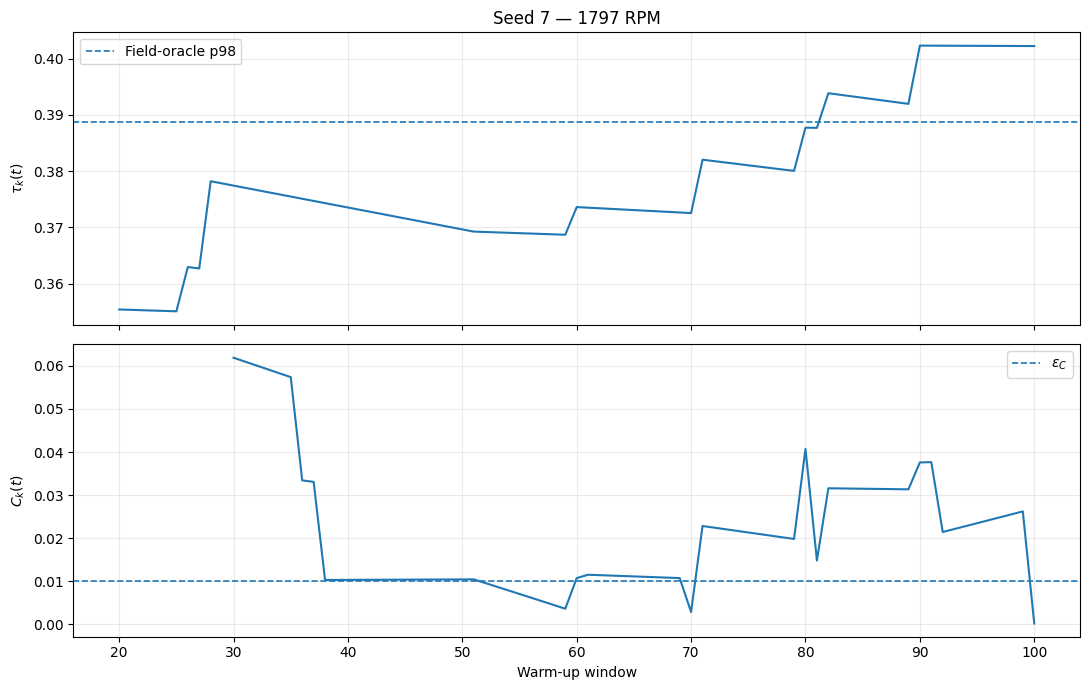

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

steps = np.arange(1, len(tau_history) + 1)

axes[0].plot(steps, tau_history, linewidth=1.5)
axes[0].axhline(
    trace["tau_field_oracle"],
    linestyle="--",
    linewidth=1.2,
    label="Field-oracle p98",
)
axes[0].set_ylabel(r"$\tau_k(t)$")
axes[0].set_title("Seed 7 — 1797 RPM")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(steps, convergence_trace, linewidth=1.5)
axes[1].axhline(
    CONVERGENCE_TOLERANCE,
    linestyle="--",
    linewidth=1.2,
    label=r"$\varepsilon_C$",
)
axes[1].set_xlabel("Warm-up window")
axes[1].set_ylabel(r"$C_k(t)$")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [16]:
results = {}

for bearing_id in [1730, 1750, 1772, 1797]:

    (
        mse_healthy,
        mse_ball,
        mse_inner,
        mse_outer,
        tau_mc,
        tau_bridge,
        tau_p98,
        tau_adaptive
    ) = run_experiment(bearing_id)

    results[str(bearing_id)] = {
        "mse_healthy": mse_healthy,
        "tau_bridge": tau_bridge,
        "tau_p98": tau_p98,
        "tau_adaptive": tau_adaptive
    }


CWRU operating condition: 1730 RPM
Normal: (485643, 1)
Ball:   (486812, 1)
Inner:  (488144, 1)
Outer:  (854807, 1)


NameError: name 'X_train' is not defined

In [ ]:
# =====================================================================
# EDGE FOOTPRINT MEASUREMENT
# Requires: shared_ae, shared_sig_len
# =====================================================================

import os
import time
import tempfile


# ---------------------------------------------------------------------
# 1. Parameter and raw-weight size
# ---------------------------------------------------------------------

parameter_count = shared_ae.count_params()

float32_weight_bytes = parameter_count * np.dtype(np.float32).itemsize
float32_weight_mb = float32_weight_bytes / 1_000_000
float32_weight_mib = float32_weight_bytes / (1024 ** 2)


# ---------------------------------------------------------------------
# 2. Exact serialized model size
# Save without optimizer state, because deployment uses inference only.
# ---------------------------------------------------------------------

with tempfile.TemporaryDirectory() as tmpdir:
    keras_path = os.path.join(tmpdir, "shared_oem_model.keras")

    # Clone/compile state is not required for inference.
    shared_ae.save(
        keras_path,
        include_optimizer=False,
    )

    serialized_bytes = os.path.getsize(keras_path)
    serialized_mb = serialized_bytes / 1_000_000
    serialized_mib = serialized_bytes / (1024 ** 2)


# ---------------------------------------------------------------------
# 3. Local calibration-state size
# Compact implementation: 100 float32 residuals plus a few scalar values.
# ---------------------------------------------------------------------

LOCAL_BUFFER_LENGTH = 100

residual_buffer_bytes = (
    LOCAL_BUFFER_LENGTH * np.dtype(np.float32).itemsize
)

# Example compact scalar state:
# current tau, previous tau, percentile, tolerance,
# convergence counter, state flag, and sample counter.
estimated_scalar_state_bytes = (
    4 * np.dtype(np.float32).itemsize
    + 3 * np.dtype(np.int32).itemsize
)

local_state_bytes = (
    residual_buffer_bytes + estimated_scalar_state_bytes
)


# ---------------------------------------------------------------------
# 4. Batch-1 CPU inference latency
# Use a real-shaped input. shared_ae is kept fixed.
# ---------------------------------------------------------------------

benchmark_input = np.zeros(
    (1, shared_sig_len, 1),
    dtype=np.float32,
)

benchmark_tensor = tf.convert_to_tensor(benchmark_input)

# Warm-up: TensorFlow tracing, memory allocation, and caches
N_WARMUP = 50
for _ in range(N_WARMUP):
    _ = shared_ae(
        benchmark_tensor,
        training=False,
    )

# Timed runs
N_RUNS = 500
latencies_ms = []

for _ in range(N_RUNS):
    start = time.perf_counter()

    output = shared_ae(
        benchmark_tensor,
        training=False,
    )

    # Force completion before stopping the clock
    _ = output.numpy()

    elapsed_ms = (
        time.perf_counter() - start
    ) * 1000.0

    latencies_ms.append(elapsed_ms)

latencies_ms = np.asarray(latencies_ms)

latency_median_ms = float(np.median(latencies_ms))
latency_mean_ms = float(np.mean(latencies_ms))
latency_std_ms = float(np.std(latencies_ms, ddof=1))
latency_p95_ms = float(np.percentile(latencies_ms, 95))


# ---------------------------------------------------------------------
# 5. Results
# ---------------------------------------------------------------------

edge_footprint = pd.DataFrame(
    [
        {
            "metric": "Model parameters",
            "value": f"{parameter_count:,}",
        },
        {
            "metric": "Raw float32 weight size",
            "value": (
                f"{float32_weight_mb:.2f} MB "
                f"({float32_weight_mib:.2f} MiB)"
            ),
        },
        {
            "metric": "Serialized .keras size",
            "value": (
                f"{serialized_mb:.2f} MB "
                f"({serialized_mib:.2f} MiB)"
            ),
        },
        {
            "metric": "CPU latency, median",
            "value": f"{latency_median_ms:.3f} ms/window",
        },
        {
            "metric": "CPU latency, mean ± std",
            "value": (
                f"{latency_mean_ms:.3f} ± "
                f"{latency_std_ms:.3f} ms/window"
            ),
        },
        {
            "metric": "CPU latency, p95",
            "value": f"{latency_p95_ms:.3f} ms/window",
        },
        {
            "metric": "Local residual-buffer length",
            "value": str(LOCAL_BUFFER_LENGTH),
        },
        {
            "metric": "Residual-buffer memory",
            "value": f"{residual_buffer_bytes} bytes",
        },
        {
            "metric": "Estimated compact local state",
            "value": (
                f"{local_state_bytes} bytes "
                f"(< 1 kB)"
            ),
        },
        {
            "metric": "Per-asset model training",
            "value": "None",
        },
        {
            "metric": "Fault labels required",
            "value": "None",
        },
    ]
)

display(edge_footprint)